<a href="https://colab.research.google.com/github/youenimmay/Stworkshop25/blob/main/Assignment%202%20-%20Analyzing%20Music%20Trends.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# New Section

### Research Question 1: How has what listeners consider as “popular music” seemed to change over time?

To answer this, we will analyze the trends of various audio features over the years for popular tracks. We'll start by extracting the release year and then look at the average audio features for tracks with above-average popularity across different years.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'release_date' is in datetime format and extract the year
spotify_tracks_df_cleaned['release_year'] = pd.to_datetime(spotify_tracks_df_cleaned['release_date'], errors='coerce').dt.year

# Drop rows where release_year could not be parsed
spotify_tracks_df_cleaned.dropna(subset=['release_year'], inplace=True)
spotify_tracks_df_cleaned['release_year'] = spotify_tracks_df_cleaned['release_year'].astype(int)

# Define 'popular' tracks for this analysis (e.g., above the median popularity for each year)
# Or we can use the overall 75th percentile as used in classification for consistency
# For time series analysis, let's consider tracks that are simply above the overall average popularity.

overall_avg_popularity = spotify_tracks_df_cleaned['popularity'].mean()
popular_tracks_over_time = spotify_tracks_df_cleaned[spotify_tracks_df_cleaned['popularity'] >= overall_avg_popularity].copy()

# Group by year and calculate the mean of audio features for popular tracks
annual_feature_trends = popular_tracks_over_time.groupby('release_year')[audio_features + ['popularity']].mean()

# Filter for a reasonable range of years to avoid sparse data at extremes
annual_feature_trends = annual_feature_trends[(annual_feature_trends.index >= 1950) & (annual_feature_trends.index <= 2020)]

print("Annual average audio features for popular tracks (first 5 rows):")
display(annual_feature_trends.head())

# Plotting the trends of selected audio features
plt.figure(figsize=(16, 10))

selected_features_to_plot = [
    'danceability', 'energy', 'acousticness', 'valence', 'loudness', 'tempo'
]

for i, feature in enumerate(selected_features_to_plot):
    plt.subplot(3, 2, i + 1)
    sns.lineplot(x=annual_feature_trends.index, y=annual_feature_trends[feature])
    plt.title(f'Trend of {feature.replace("_", " ").title()} in Popular Music Over Time')
    plt.xlabel('Year')
    plt.ylabel(feature.replace("_", " ").title())
    plt.grid(True)

plt.tight_layout()
plt.show()

# Also plot the trend of average popularity itself
plt.figure(figsize=(12, 6))
sns.lineplot(x=annual_feature_trends.index, y=annual_feature_trends['popularity'])
plt.title('Trend of Average Popularity of Selected Tracks Over Time')
plt.xlabel('Year')
plt.ylabel('Average Popularity')
plt.grid(True)
plt.show()

print("\nAnalysis of trends in audio features and popularity over time completed.")

### 5. Classification: Hit vs. Non-Hit

To classify tracks as 'hits' or 'non-hits', we first need to define these categories. We'll use the 'popularity' score from the `spotify_tracks_df_cleaned` DataFrame. A common way to define a 'hit' is to consider tracks above a certain popularity threshold or percentile. For this exercise, let's define a 'hit' as any track with a popularity score above the 75th percentile of the dataset.

75th percentile of popularity scores: 41.00

Distribution of 'is_hit' classes:


,count
is_hit,
0,438991
1,147681



Shape of X_train_cls: (469337, 13)
Shape of X_test_cls: (117335, 13)
Shape of y_train_cls: (469337,)
Shape of y_test_cls: (117335,)

Classification Metrics:
Accuracy: 0.71
Precision: 0.36
Recall: 0.20
F1-Score: 0.26


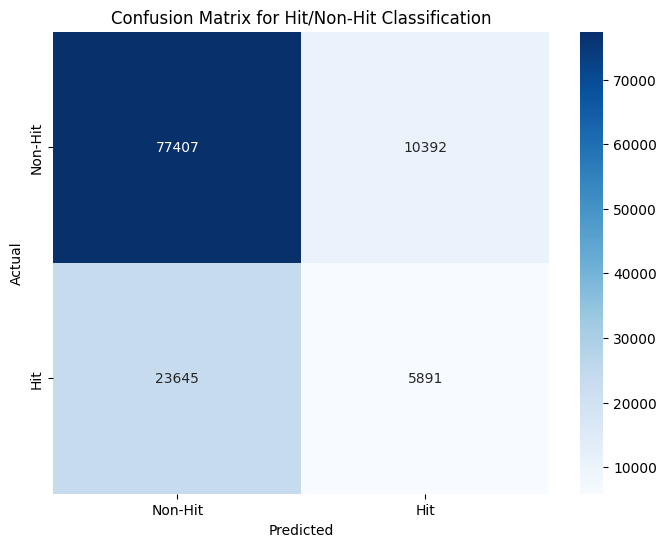

In [10]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the 75th percentile of the 'popularity' score
popularity_threshold = spotify_tracks_df_cleaned['popularity'].quantile(0.75)
print(f"75th percentile of popularity scores: {popularity_threshold:.2f}")

# Create the binary target variable 'is_hit'
# 1 for 'hit' (popularity >= threshold), 0 for 'non-hit'
spotify_tracks_df_cleaned['is_hit'] = (spotify_tracks_df_cleaned['popularity'] >= popularity_threshold).astype(int)

print("\nDistribution of 'is_hit' classes:")
display(spotify_tracks_df_cleaned['is_hit'].value_counts())

# Define features (X) and the new target (y_hit) for classification
# We'll use the same audio features as before
X_cls = spotify_tracks_df_cleaned[audio_features]
y_cls = spotify_tracks_df_cleaned['is_hit']

# Split the data into training and testing sets for classification
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls) # Stratify to maintain class distribution

print(f"\nShape of X_train_cls: {X_train_cls.shape}")
print(f"Shape of X_test_cls: {X_test_cls.shape}")
print(f"Shape of y_train_cls: {y_train_cls.shape}")
print(f"Shape of y_test_cls: {y_test_cls.shape}")

# Initialize and train a K-Nearest Neighbors (KNN) classifier
# Choosing a simple model as requested. n_neighbors can be tuned.
knn_model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1) # n_jobs=-1 uses all available cores
knn_model.fit(X_train_cls, y_train_cls)

# Make predictions on the test set
y_pred_cls = knn_model.predict(X_test_cls)

# Evaluate the classifier
accuracy = accuracy_score(y_test_cls, y_pred_cls)
precision = precision_score(y_test_cls, y_pred_cls)
recall = recall_score(y_test_cls, y_pred_cls)
f1 = f1_score(y_test_cls, y_pred_cls)

print(f"\nClassification Metrics:")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

# Confusion Matrix
cm = confusion_matrix(y_test_cls, y_pred_cls)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Hit', 'Hit'], yticklabels=['Non-Hit', 'Hit'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Hit/Non-Hit Classification')
plt.show()


### 5. Classification: Hit vs. Non-Hit

To classify tracks as 'hits' or 'non-hits', we first need to define these categories. We'll use the 'popularity' score from the `spotify_tracks_df_cleaned` DataFrame. A common way to define a 'hit' is to consider tracks above a certain popularity threshold or percentile. For this exercise, let's define a 'hit' as any track with a popularity score above the 75th percentile of the dataset.

75th percentile of popularity scores: 41.00

Distribution of 'is_hit' classes:


,count
is_hit,
0,438991
1,147681



Shape of X_train_cls: (469337, 13)
Shape of X_test_cls: (117335, 13)
Shape of y_train_cls: (469337,)
Shape of y_test_cls: (117335,)

Classification Metrics:
Accuracy: 0.71
Precision: 0.36
Recall: 0.20
F1-Score: 0.26


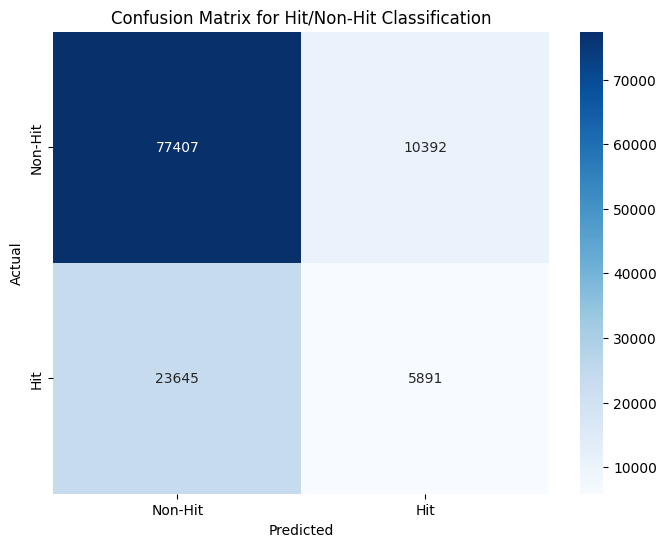

In [11]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the 75th percentile of the 'popularity' score
popularity_threshold = spotify_tracks_df_cleaned['popularity'].quantile(0.75)
print(f"75th percentile of popularity scores: {popularity_threshold:.2f}")

# Create the binary target variable 'is_hit'
# 1 for 'hit' (popularity >= threshold), 0 for 'non-hit'
spotify_tracks_df_cleaned['is_hit'] = (spotify_tracks_df_cleaned['popularity'] >= popularity_threshold).astype(int)

print("\nDistribution of 'is_hit' classes:")
display(spotify_tracks_df_cleaned['is_hit'].value_counts())

# Define features (X) and the new target (y_hit) for classification
# We'll use the same audio features as before
X_cls = spotify_tracks_df_cleaned[audio_features]
y_cls = spotify_tracks_df_cleaned['is_hit']

# Split the data into training and testing sets for classification
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls) # Stratify to maintain class distribution

print(f"\nShape of X_train_cls: {X_train_cls.shape}")
print(f"Shape of X_test_cls: {X_test_cls.shape}")
print(f"Shape of y_train_cls: {y_train_cls.shape}")
print(f"Shape of y_test_cls: {y_test_cls.shape}")

# Initialize and train a K-Nearest Neighbors (KNN) classifier
# Choosing a simple model as requested. n_neighbors can be tuned.
knn_model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1) # n_jobs=-1 uses all available cores
knn_model.fit(X_train_cls, y_train_cls)

# Make predictions on the test set
y_pred_cls = knn_model.predict(X_test_cls)

# Evaluate the classifier
accuracy = accuracy_score(y_test_cls, y_pred_cls)
precision = precision_score(y_test_cls, y_pred_cls)
recall = recall_score(y_test_cls, y_pred_cls)
f1 = f1_score(y_test_cls, y_pred_cls)

print(f"\nClassification Metrics:")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

# Confusion Matrix
cm = confusion_matrix(y_test_cls, y_pred_cls)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Hit', 'Hit'], yticklabels=['Non-Hit', 'Hit'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Hit/Non-Hit Classification')
plt.show()


### 1. Kaggle Setup and Data Download

First, we need to install the Kaggle API client and download the datasets. If you haven't already, please upload your `kaggle.json` file (obtained from your Kaggle account settings) to the Colab environment. Then, run the following commands to move it to the correct location and set permissions.

In [5]:
import os

# Install the Kaggle API client
!pip install kaggle

# Create a .kaggle directory if it doesn't exist
!mkdir -p ~/.kaggle

# Instructions for kaggle.json. Ensure you run these in a separate cell after uploading kaggle.json.
# !mv kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json

print("Please ensure your kaggle.json is uploaded and moved to ~/.kaggle/ with correct permissions. Once done, you can run the download commands below.")

Please ensure your kaggle.json is uploaded and moved to ~/.kaggle/ with correct permissions. Once done, you can run the download commands below.


After setting up your Kaggle API key, run the following cell to download and unzip the specified datasets.

In [6]:
# Download the Spotify Tracks dataset
!kaggle datasets download -d yamaerenay/spotify-dataset-19212020-600k-tracks -p ./data/spotify_tracks/

# Unzip the downloaded file
!unzip -o ./data/spotify_tracks/spotify-dataset-19212020-600k-tracks.zip -d ./data/spotify_tracks/

# Download the Daily Top 200 charts dataset
!kaggle datasets download -d pepepython/spotify-huge-database-daily-charts-over-3-years -p ./data/daily_charts/

# Unzip the downloaded file
!unzip -o ./data/daily_charts/spotify-huge-database-daily-charts-over-3-years.zip -d ./data/daily_charts/

print("Datasets downloaded and unzipped.")

Dataset URL: https://www.kaggle.com/datasets/yamaerenay/spotify-dataset-19212020-600k-tracks
License(s): Community Data License Agreement - Sharing - Version 1.0
spotify-dataset-19212020-600k-tracks.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  ./data/spotify_tracks/spotify-dataset-19212020-600k-tracks.zip
  inflating: ./data/spotify_tracks/artists.csv  
  inflating: ./data/spotify_tracks/dict_artists.json  
  inflating: ./data/spotify_tracks/tracks.csv  
Dataset URL: https://www.kaggle.com/datasets/pepepython/spotify-huge-database-daily-charts-over-3-years
License(s): unknown
spotify-huge-database-daily-charts-over-3-years.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  ./data/daily_charts/spotify-huge-database-daily-charts-over-3-years.zip
  inflating: ./data/daily_charts/Database to calculate popularity.csv  
  inflating: ./data/daily_charts/Final database.csv  
Datasets downloaded an

### 2. Load Data into Pandas DataFrames

Now, let's load the `tracks.csv` file into a pandas DataFrame, which we will use for the popularity regression task. We'll also load the other relevant CSV files.

In [7]:
import pandas as pd

# Load the Spotify tracks dataset from 'tracks.csv'
spotify_tracks_df = pd.read_csv('./data/spotify_tracks/tracks.csv')
print("Spotify Tracks DataFrame loaded. First 5 rows:")
display(spotify_tracks_df.head())

# Load the artists dataset (optional for this task, but good to have)
artists_df = pd.read_csv('./data/spotify_tracks/artists.csv')
print("\nArtists DataFrame loaded. First 5 rows:")
display(artists_df.head())

# Load the daily charts data, using 'Final database.csv' as it's typically the main dataset
try:
    daily_charts_df = pd.read_csv('./data/daily_charts/Final database.csv')
    print("\nDaily Charts DataFrame loaded. First 5 rows:")
    display(daily_charts_df.head())
except FileNotFoundError:
    print("Warning: 'Final database.csv' not found. Please check the file name in './data/daily_charts/'.")
    print("Available files in './data/daily_charts/':", os.listdir('./data/daily_charts/'))
    daily_charts_df = pd.DataFrame() # Create an empty DataFrame to avoid errors later


Spotify Tracks DataFrame loaded. First 5 rows:


,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,35iwgR4jXetI318WEWsa1Q,Carve,6,126903,0,['Uli'],['45tIt06XoI0Iio4LBEVpls'],1922-02-22,0.645,0.4450,0,-13.338,1,0.4510,0.674,0.7440,0.151,0.127,104.851,3
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98200,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.695,0.2630,0,-22.136,1,0.9570,0.797,0.0000,0.148,0.655,102.009,1
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181640,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.434,0.1770,1,-21.180,1,0.0512,0.994,0.0218,0.212,0.457,130.418,5
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176907,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.321,0.0946,7,-27.961,1,0.0504,0.995,0.9180,0.104,0.397,169.980,3
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163080,0,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],1922,0.402,0.1580,3,-16.900,0,0.0390,0.989,0.1300,0.311,0.196,103.220,4



Artists DataFrame loaded. First 5 rows:


,id,followers,genres,name,popularity
0,0DheY5irMjBUeLybbCUEZ2,0.0,[],Armid & Amir Zare Pashai feat. Sara Rouzbehani,0
1,0DlhY15l3wsrnlfGio2bjU,5.0,[],ปูนา ภาวิณี,0
2,0DmRESX2JknGPQyO15yxg7,0.0,[],Sadaa,0
3,0DmhnbHjm1qw6NCYPeZNgJ,0.0,[],Tra'gruda,0
4,0Dn11fWM7vHQ3rinvWEl4E,2.0,[],Ioannis Panoutsopoulos,0


/tmp/ipykernel_314/932125218.py:15: DtypeWarning: Columns (7,8,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25) have mixed types. Specify dtype option on import or set low_memory=False.
  daily_charts_df = pd.read_csv('./data/daily_charts/Final database.csv')



Daily Charts DataFrame loaded. First 5 rows:


,Country,Uri,Popularity,Title,Artist,Album/Single,Genre,Artist_followers,Explicit,Album,...,Sweden,Switzerland,Taiwan,Turkey,UK,USA,Popu_max,Top10_dummy,Top50_dummy,Cluster
0,Global,https://open.spotify.com/track/6FyRXC8tJUh863J...,31833.95,adan y eva,Paulo Londra,single,argentine hip hop,11427104.0,False,Adan y Eva,...,0,0,0,0,0,0,10,1.0,1.0,global
1,USA,https://open.spotify.com/track/6FyRXC8tJUh863J...,8.00,adan y eva,Paulo Londra,single,argentine hip hop,11427104.0,False,Adan y Eva,...,0,0,0,0,0,1,191,0.0,0.0,english speaking and nordic
2,Argentina,https://open.spotify.com/track/6FyRXC8tJUh863J...,76924.40,adan y eva,Paulo Londra,single,argentine hip hop,11427104.0,False,Adan y Eva,...,0,0,0,0,0,0,1,1.0,1.0,spanish speaking
3,Belgium,https://open.spotify.com/track/6FyRXC8tJUh863J...,849.60,adan y eva,Paulo Londra,single,argentine hip hop,11427104.0,False,Adan y Eva,...,0,0,0,0,0,0,126,0.0,0.0,english speaking and nordic
4,Switzerland,https://open.spotify.com/track/6FyRXC8tJUh863J...,20739.10,adan y eva,Paulo Londra,single,argentine hip hop,11427104.0,False,Adan y Eva,...,0,1,0,0,0,0,21,0.0,1.0,english speaking and nordic


### 3. Data Preparation for Regression

Now that `spotify_tracks_df` is loaded, we'll prepare the data for our regression model. This involves defining our features (audio features) and target variable (popularity), and handling any missing values.

In [8]:
import pandas as pd

# Identify audio features and the 'popularity' column
# These are commonly found audio features in Spotify datasets.
audio_features = [
    'danceability',
    'energy',
    'key',
    'loudness',
    'mode',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'duration_ms',
    'time_signature'
]

target_variable = 'popularity'

# Check if all identified columns exist in the DataFrame
missing_cols_in_df = [col for col in audio_features + [target_variable] if col not in spotify_tracks_df.columns]
if missing_cols_in_df:
    print(f"\nWarning: The following expected columns are missing from spotify_tracks_df: {missing_cols_in_df}")
    # Filter audio_features to only include existing columns
    audio_features = [col for col in audio_features if col not in missing_cols_in_df]
else:
    print("\nAll expected audio features and target variable are present in spotify_tracks_df.")

# Check for missing values in the selected columns in the original DataFrame
print("\nMissing values in selected columns (before cleaning):")
display(spotify_tracks_df[audio_features + [target_variable]].isnull().sum())

# Drop rows with any missing values in our selected features/target for simplicity
spotify_tracks_df_cleaned = spotify_tracks_df.dropna(subset=audio_features + [target_variable])
print(f"\nDataFrame shape after dropping NaNs: {spotify_tracks_df_cleaned.shape}")


All expected audio features and target variable are present in spotify_tracks_df.

Missing values in selected columns (before cleaning):


,0
danceability,0
energy,0
key,0
loudness,0
mode,0
speechiness,0
acousticness,0
instrumentalness,0
liveness,0
valence,0



DataFrame shape after dropping NaNs: (586672, 20)


### 4. Regression Model Training and Evaluation

Now we will split the cleaned data, train a Random Forest Regressor model, and evaluate its performance using Mean Squared Error (MSE) and R-squared (R²). We'll also visualize the distribution of residuals and feature importances.

Shape of X_train: (469337, 13)
Shape of X_test: (117335, 13)
Shape of y_train: (469337,)
Shape of y_test: (117335,)

Mean Squared Error (MSE): 206.97
R-squared (R²): 0.38


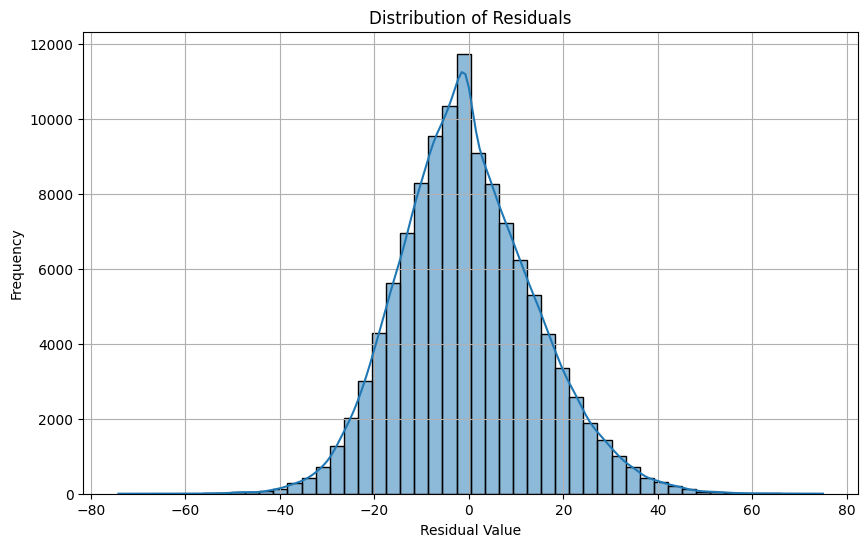

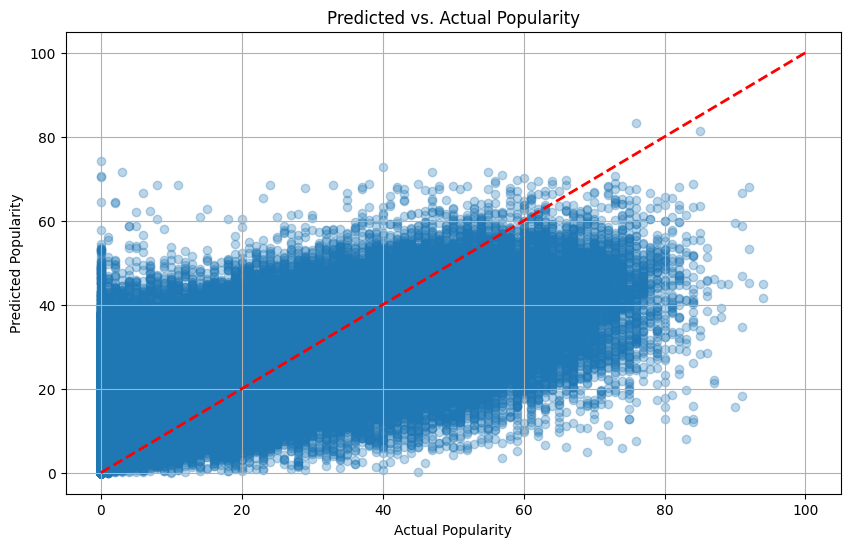

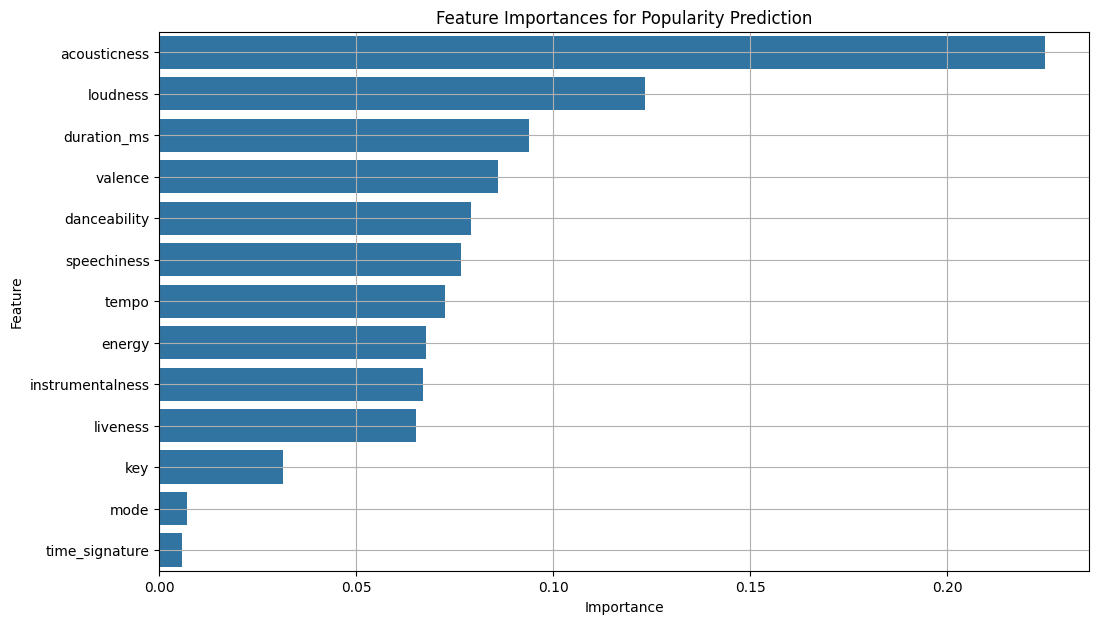

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define features (X) and target (y) from the cleaned DataFrame
X = spotify_tracks_df_cleaned[audio_features]
y = spotify_tracks_df_cleaned[target_variable]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Initialize and train the Random Forest Regressor model
# Using n_estimators=100 for a reasonable balance between performance and speed.
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available cores
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nMean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R²): {r2:.2f}")

# Calculate residuals
residuals = y_test - y_pred

# Plotting the distribution of residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=50)
plt.title('Distribution of Residuals')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Plotting predicted vs. actual values to assess model fit visually
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Line for perfect prediction
plt.title('Predicted vs. Actual Popularity')
plt.xlabel('Actual Popularity')
plt.ylabel('Predicted Popularity')
plt.grid(True)
plt.show()

# Feature Importances: Helps understand which audio features are most influential
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
plt.figure(figsize=(12, 7))
sns.barplot(x=feature_importances.sort_values(ascending=False), y=feature_importances.sort_values(ascending=False).index)
plt.title('Feature Importances for Popularity Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(True)
plt.show()